<a href="https://www.kaggle.com/code/fluloeo/inference-qwen?scriptVersionId=308184854" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [12]:
!pip install "protobuf<5" vllm transformers langchain langgraph chromadb -U -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 49.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 63.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.0/64.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. 

## Импорты и загрузка модели

In [3]:
import numpy as np 
import pandas as pd 
import os
import ast
from tqdm import tqdm
from typing import List
from vllm import LLM, SamplingParams
from langchain_core.runnables import RunnableLambda
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer
import torch
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


model_id = "Qwen/Qwen3-4B-Instruct-2507"
llm = LLM(
    model= model_id,
    tensor_parallel_size=2,  
    max_model_len=16384,     
    gpu_memory_utilization=0.85,
    attention_backend="TRITON_ATTN",
    dtype="float16" 
)
tokenizer = AutoTokenizer.from_pretrained(model_id)

2026-04-01 10:57:32.236260: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775041052.457084      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775041052.523349      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775041053.041083      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775041053.041117      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775041053.041120      55 computation_placer.cc:177] computation placer alr

/kaggle/input/df-dict-test/df_dict_test.csv
INFO 04-01 10:57:53 [utils.py:261] non-default args: {'dtype': 'float16', 'max_model_len': 16384, 'tensor_parallel_size': 2, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'attention_backend': 'TRITON_ATTN', 'model': 'Qwen/Qwen3-4B-Instruct-2507'}


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

INFO 04-01 10:58:13 [model.py:541] Resolved architecture: Qwen3ForCausalLM
WARNING 04-01 10:58:13 [model.py:1885] Casting torch.bfloat16 to torch.float16.
INFO 04-01 10:58:13 [model.py:1561] Using max model len 16384
INFO 04-01 10:58:13 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-01 10:58:13 [vllm.py:624] Asynchronous scheduling is enabled.


generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

...

(Worker_TP0 pid=256) INFO 04-01 11:00:32 [backends.py:302] Cache the graph of compile range (1, 8192) for later use
(Worker_TP1 pid=257) INFO 04-01 11:00:33 [backends.py:302] Cache the graph of compile range (1, 8192) for later use
(Worker_TP0 pid=256) INFO 04-01 11:00:44 [backends.py:319] Compiling a graph for compile range (1, 8192) takes 24.44 s
(Worker_TP0 pid=256) INFO 04-01 11:00:44 [monitor.py:34] torch.compile takes 43.39 s in total
(Worker_TP0 pid=256) INFO 04-01 11:00:47 [gpu_worker.py:356] Available KV cache memory: 7.05 GiB
(EngineCore_DP0 pid=232) INFO 04-01 11:00:47 [kv_cache_utils.py:1307] GPU KV cache size: 102,704 tokens
(EngineCore_DP0 pid=232) INFO 04-01 11:00:47 [kv_cache_utils.py:1312] Maximum concurrency for 16,384 tokens per request: 6.27x


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:06<00:00,  7.87it/s]
Capturing CUDA graphs (decode, FULL):  97%|█████████▋| 34/35 [00:10<00:00,  3.26it/s]

(Worker_TP1 pid=257) INFO 04-01 11:01:06 [custom_all_reduce.py:216] Registering 6278 cuda graph addresses


Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:12<00:00,  2.90it/s]


(Worker_TP0 pid=256) INFO 04-01 11:01:06 [custom_all_reduce.py:216] Registering 6278 cuda graph addresses
(Worker_TP0 pid=256) INFO 04-01 11:01:07 [gpu_model_runner.py:5051] Graph capturing finished in 20 secs, took 0.52 GiB
(EngineCore_DP0 pid=232) INFO 04-01 11:01:07 [core.py:272] init engine (profile, create kv cache, warmup model) took 79.08 seconds
(EngineCore_DP0 pid=232) INFO 04-01 11:01:12 [vllm.py:624] Asynchronous scheduling is enabled.
INFO 04-01 11:01:12 [llm.py:343] Supported tasks: ['generate']


## Проверка запуска модели

In [4]:
sampling_params = SamplingParams(temperature = 0, max_tokens=512)
messages = [{"role": "user", "content": "Кратко расскажи о больших языковых моделях."}]

prompt = tokenizer.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

outputs = llm.generate([prompt], sampling_params)
for output in outputs:
    print(f"Ответ: {output.outputs[0].text}\n")

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Ответ: Большие языковые модели (БЯМ) — это искусственные интеллект-системы, обученные на огромных объёмах текстовых данных для понимания и генерации человеческих языковых конструкций. Они используют глубокие нейронные сети (обычно на основе трансформеров) и способны предсказывать следующие слова, строить связные тексты, отвечать на вопросы, суммировать информацию, писать письма, код и многое другое.

Ключевые особенности:

- **Обучение на больших объёмах текста** (миллиарды слов).
- **Понимание контекста** — учитывают последовательность слов.
- **Генерация текста** — могут создавать естественные, логичные фразы.
- **Масштабируемость** — модели, такие как GPT, Llama, BERT, могут быть адаптированы под разные задачи.

БЯМ широко применяются в чат-ботах, роботах-ассистентах, переводчиках, редактировании текстов, анализе данных и других областях. Однако они могут ошибаться, быть неэтичными или генерировать непроверенную информацию — поэтому важно использовать их с осторожностью и в сочетани

## Минимальная обработка чанков датасета

In [5]:
def to_full_text(data_dict):
    """Превращает словарь разделов в единый текст."""
    return "\n\n".join([f"{k}\n{v}" for k, v in data_dict.items()])

def get_token_length(text: str) -> int:
    return len(tokenizer.encode(text))

def merge_small_chunks_by_tokens(chunks: List[str], min_tokens: int) -> List[str]:
    """
    Объединяет чанки, если их длина в ТОКЕНАХ меньше min_tokens.
    Слияние происходит с наименьшим соседом (по количеству токенов).
    """
    processed_chunks = chunks[:]
    separator = " " 
    
    i = 0
    while i < len(processed_chunks):
        current_chunk = processed_chunks[i]
        current_len = get_token_length(current_chunk)
        if current_len >= min_tokens:
            i += 1
            continue
        if len(processed_chunks) == 1:
            break
        if i > 0:
            left_len = get_token_length(processed_chunks[i-1])
        else:
            left_len = float('inf')

        if i < len(processed_chunks) - 1:
            right_len = get_token_length(processed_chunks[i+1])
        else:
            right_len = float('inf')
        if left_len < right_len:
            processed_chunks[i-1] = processed_chunks[i-1] + separator + processed_chunks[i]
            processed_chunks.pop(i)
            i -= 1 
        else:
            processed_chunks[i] = processed_chunks[i] + separator + processed_chunks[i+1]
            processed_chunks.pop(i+1)
    return processed_chunks
    
def merge_chunks_in_dataset(df, min_tokens=100, n=100, n_threshold = 10):
    data = pd.DataFrame(columns=['chunks'])
    max_len_chunks = []
    max_size_chunks = []
    min_size_chunks = []
    for i in range(n):
        data_dict = ast.literal_eval(df['dict_test'].iloc[i])
        tokens_chunks_list_0 = list(map(lambda x: get_token_length(x), list(data_dict.values())))
        if len(tokens_chunks_list_0)>n_threshold or min(tokens_chunks_list_0)<min_tokens:
            final_chunks = merge_small_chunks_by_tokens(list(data_dict.values()), min_tokens=min_tokens)
            # print(f"\nКонечное количество чанков: {len(final_chunks)}\n")
            tokens_chunks_list = list(map(lambda x: get_token_length(x), final_chunks))
            # print('Максимальный размер чанка',max(tokens_chunks_list),'\n')
            max_len_chunks.append(len(final_chunks))
            max_size_chunks.append(max(tokens_chunks_list))
            min_size_chunks.append(min(tokens_chunks_list))
            data.loc[len(data)] = [final_chunks]
        else:
            print("Ничего не меняем, кол-во чанков, мин токенов", len(tokens_chunks_list_0),min(tokens_chunks_list_0))
            data.loc[len(data)] = [data_dict]
    print('Максимальное Кол-во чанков из всех статей\n',(max(max_len_chunks)))
    print('Минимальное Кол-во чанков из всех статей\n',(min(max_len_chunks)))
    print('Максимальный размер чанка из всех статей\n',max(max_size_chunks))
    print('Минимальный размер чанка из всех статей\n',min(min_size_chunks))
    return data
df = pd.read_csv('/kaggle/input/df-dict-test/df_dict_test.csv')
data = merge_chunks_in_dataset(df=df, min_tokens=700, n=20,n_threshold = 10)

Максимальное Кол-во чанков из всех статей
 14
Минимальное Кол-во чанков из всех статей
 5
Максимальный размер чанка из всех статей
 3331
Минимальный размер чанка из всех статей
 706


## Суммаризация

In [7]:
def vllm_gen(prompts, max_new_tokens):
    """Принимает список промптов и лимит токенов."""
    if not prompts: return []
    current_params = SamplingParams(
        temperature=0, 
        max_tokens=max_new_tokens
    )
    
    outputs = llm.generate(prompts, current_params)
    return [output.outputs[0].text for output in outputs]

def process_chunks(pre_parsed_chunks, max_chunk_tokens=3000):
    """
    Проверяет готовые чанки. Если чанк слишком большой, дробит его.
    """
    splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer=tokenizer,
        chunk_size=max_chunk_tokens,
        chunk_overlap=200
    )
    
    final_chunks = []
    for chunk in pre_parsed_chunks:
        token_count = len(tokenizer.encode(chunk))
        if token_count <= max_chunk_tokens:
            final_chunks.append(chunk)
        else:
            sub_chunks = splitter.split_text(chunk)
            final_chunks.extend(sub_chunks)
            
    return final_chunks

def prepare_prompt(text, system_prompt):
    messages = [{"role": "user", "content": f"{system_prompt}:\n\n{text}"}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def run_summarization_pipeline(pre_parsed_chunks, p0, p1):
    ready_chunks = process_chunks(pre_parsed_chunks, max_chunk_tokens=3500)

    map_prompts = [prepare_prompt(c, p0) for c in ready_chunks]
    chunk_summaries = gen_chunks_runnable.invoke(map_prompts)
    
    combined_text = "\n".join(chunk_summaries)
    
    reduce_prompt = prepare_prompt(combined_text, p1)
    final_summaries = gen_final_runnable.invoke([reduce_prompt])
    return final_summaries[0]

summaries_list = []
gen_chunks_runnable = RunnableLambda(lambda x: vllm_gen(x, max_new_tokens=512))
gen_final_runnable = RunnableLambda(lambda x: vllm_gen(x, max_new_tokens=1280))
prompt_0 = """Act as a professional Science Editor. 
Your task is to extract key information from this fragment of a scientific paper.
1. Identify specific objectives, technical methodologies, and key data mentioned.
2. Maintain technical terminology and the original language.
3. Be objective: do not add interpretations or info not present in the text.
4. Output format: Use a dense bulleted list of the most important points.
5. Avoid any introductory or concluding remarks—just the facts."""
prompt_1 = """Act as a Senior Science Editor. 
Task: Synthesize a single, coherent executive summary based on the provided fragment summaries.

Structure your response strictly as follows:
- **Goal**: Clear statement of the research objective and problem.
- **Methods**: Summary of the technical approach, experiments, or theoretical framework.
- **Results**: Detailed overview of key findings and performance improvements.
- **Conclusion**: The overall significance and final takeaway.

Requirements:
- Style: Academic, professional, and precise.
- Formulas: Do not use any mathematical formulas or LaTeX. Describe results in words.
- Length: Aim for 500-650 words. Ensure information density is high.
- Integrity: Ensure the text ends with a complete, definitive concluding sentence.
- Do not add any text outside of the headers. Final summary only."""



Проверка

In [ ]:
for i in range(20): #len(data)
    torch.cuda.empty_cache()
    print(f"\n=== Обработка статьи {i} ===")
    current_article_chunks = data['chunks'].iloc[i] 
    try:
        summary = run_summarization_pipeline(current_article_chunks, prompt_0, prompt_1)
        article = to_full_text(ast.literal_eval(df['dict_test'].iloc[i]))
        print(f"Статья {i} готова. Итоговых токенов: {len(tokenizer.encode(summary))}")
        summaries_list.append({
            'article_id': i,
            'summary': summary,
            'abstract': df['abstract'].iloc[i],
            'article': article
        })
    except Exception as e:
        print(f"Ошибка на статье {i}: {e}")

pd.DataFrame(summaries_list).to_csv('summaries.csv')
data_load = pd.read_csv('/kaggle/working/summaries.csv')
data_load.head()

In [ ]:
from IPython.display import display, Markdown
for i in range(20):
    display(Markdown(f"# Статья {i}"))
    display(Markdown("## Abstract"))
    display(Markdown(data_load['abstract'].iloc[i]))
    display(Markdown("## Summary"))
    display(Markdown(data_load['summary'].iloc[i]))
    # display(Markdown("## Original"))
    # display(Markdown(data_load['article'].iloc[i]))

# Chroma

In [14]:
import psycopg2
from kaggle_secrets import UserSecretsClient
import chromadb
from IPython.display import display, Markdown
import numpy as np 
import pandas as pd 
import os
import ast
from tqdm import tqdm
from typing import List, Dict, Tuple
from vllm import LLM, SamplingParams
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.runnables import RunnableLambda
from transformers import AutoTokenizer
import torch
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


secrets = UserSecretsClient()
db_params = {
    "dbname": "arxivdb",
    "user": secrets.get_secret("DB_USER"),
    "password": secrets.get_secret("DB_PASSWORD"),
    "host": secrets.get_secret("DB_HOST"),
    "port": "5433"  
}

with psycopg2.connect(**db_params) as conn:
    with conn.cursor() as cursor:
        print("Выгрузка данных из Postgres...")
        cursor.execute("SELECT id, title, abstract, clean_text FROM arxivdb.public.articles LIMIT 1000")
        rows = cursor.fetchall()
        
client = chromadb.PersistentClient(path="./my_rag_db")

try:
    client.delete_collection(name="scientific_papers")
except:
    pass
collection = client.create_collection(name="scientific_papers")

db_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500, 
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""]
)

all_ids = []
all_documents = []
all_metadatas = []

print("Разбивка на чанки...")
for row in rows:
    article_id, title, abstract, full_text = str(row[0]), row[1], row[2], row[3]
    
    if not full_text or len(full_text) < 10: 
        continue
        
    article_chunks = db_splitter.split_text(full_text)
    
    for i, chunk in enumerate(article_chunks):
        all_ids.append(f"{article_id}_ch_{i}")
        all_documents.append(chunk)
        all_metadatas.append({
            "article_id": article_id, 
            "title": title,
            "abstract": abstract
        })

print(f"Индексация в ChromaDB ({len(all_documents)} фрагментов)...")
batch_size = 1000
for i in tqdm(range(0, len(all_documents), batch_size)):
    collection.add(
        ids=all_ids[i : i + batch_size],
        documents=all_documents[i : i + batch_size],
        metadatas=all_metadatas[i : i + batch_size]
    )

print(f"Готово! Всего в ChromaDB: {collection.count()} записей.")


/kaggle/input/df-dict-test/df_dict_test.csv
Выгрузка данных из Postgres...
Разбивка на чанки...
Индексация в ChromaDB (26388 фрагментов)...


  0%|          | 0/27 [00:00<?, ?it/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 0.00/79.3M [00:00<?, ?iB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 340k/79.3M [00:00<00:24, 3.39MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   6%|▋         | 5.07M/79.3M [00:00<00:02, 29.9MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  16%|█▌        | 12.9M/79.3M [00:00<00:01, 52.7MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  27%|██▋       | 21.1M/79.3M [00:00<00:00, 65.2MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  37%|███▋      | 29.4M/79.3M [00:00<00:00, 72.1MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  47%|████▋     | 37.6M/79.3M [00:00<00:00, 76.2MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  58%|█████▊    | 45.9M/79.3M [00:00<00:00, 79.2MiB/s]
/root/.cache/chroma/onnx_models/all-MiniLM-

Готово! Всего в ChromaDB: 26388 записей.


# Langgraph

In [15]:
from typing import List, TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, END

# Определение состояния агента
class AgentState(TypedDict):
    query: str
    intent: str  # 'summarize' или 'rag'
    relevant_articles: List[dict]  # Список найденных статей/чанков
    summary: str
    final_answer: str

# --- Ваши существующие функции, адаптированные под vLLM ---

def get_vllm_response(prompt: str, max_tokens: int = 512):
    """Одиночный вызов vLLM для логики агента"""
    # Используем вашу функцию vllm_gen, но для одной строки
    return vllm_gen([prompt], max_tokens)[0]

# --- Узлы графа ---

def classifier_node(state: AgentState):
    """Определяет: поиск+суммаризация или точечный вопрос (RAG)"""
    query = state['query']
    prompt = f"""Task: Classify the user input.
If the user wants a general overview, search, or summary of articles on a topic, reply 'SUMMARIZE'.
If the user asks a specific factual question that requires a short precise answer, reply 'RAG'.
Input: {query}
Reply in one word (SUMMARIZE or RAG):"""
    
    decision = get_vllm_response(prompt, max_tokens=10).strip().upper()
    intent = "summarize" if "SUMMARIZE" in decision else "rag"
    return {"intent": intent}

def retriever_node(state: AgentState):
    query = state['query']
    intent = state['intent']
    
    # 1. Поиск в ChromaDB
    # n_results=5 для RAG, или n_results=10 чтобы найти несколько разных статей для обзора
    results = collection.query(
        query_texts=[query],
        n_results=10 if intent == "summarize" else 5
    )
    
    found_articles = []
    
    if intent == "summarize":
        # Логика для СУММАРИЗАЦИИ:
        # Нам нужно найти уникальные article_id среди найденных чанков
        unique_article_ids = []
        seen_ids = set()
        
        for metadata in results['metadatas'][0]:
            a_id = metadata['article_id']
            if a_id not in seen_ids:
                unique_article_ids.append({
                    "id": a_id,
                    "title": metadata['title'],
                    "abstract": metadata['abstract']
                })
                seen_ids.add(a_id)
        
        # Берем, например, топ-3 найденных статьи
        for art_info in unique_article_ids[:3]:
            # Выгружаем ВСЕ чанки для этой конкретной статьи из Chroma
            # Это нужно для полноценного Map-Reduce
            all_chunks_for_article = collection.get(
                where={"article_id": art_info['id']}
            )
            
            found_articles.append({
                "article_id": art_info['id'],
                "title": art_info['title'],
                "abstract": art_info['abstract'],
                "chunks": all_chunks_for_article['documents'] # Список всех строк текста статьи
            })
            
    else:
        # Логика для RAG (точечный ответ):
        # Нам не нужны целые статьи, только самые релевантные куски
        rag_chunks = results['documents'][0]
        # Оформляем как одну "виртуальную" статью для совместимости со State
        found_articles.append({
            "article_id": "rag_context",
            "title": "Search Results",
            "chunks": rag_chunks 
        })
    
    return {"relevant_articles": found_articles}

def summarization_node(state: AgentState):
    final_output = "# Научный обзор по вашему запросу\n\n"
    
    for article in state['relevant_articles']:
        print(f"Суммаризация статьи: {article['title']}")
        
        # Вызываем ваш существующий пайплайн (p0 и p1 - ваши промпты)
        summary = run_summarization_pipeline(article['chunks'], prompt_0, prompt_1)
        
        final_output += f"## {article['title']}\n"
        final_output += f"**Abstract:** {article['abstract']}\n\n"
        final_output += f"{summary}\n\n"
        final_output += "---\n\n"
        
    return {"final_answer": final_output}

def rag_node(state: AgentState):
    # Берем чанки из первой (единственной) "статьи" в списке
    context_chunks = state['relevant_articles'][0]['chunks']
    context_text = "\n\n".join(context_chunks)
    
    prompt = f"""Answer the question based on the provided context.
Context:
{context_text}

Question: {state['query']}
Answer:"""
    
    answer = get_vllm_response(prompt, max_tokens=1024)
    return {"final_answer": answer}

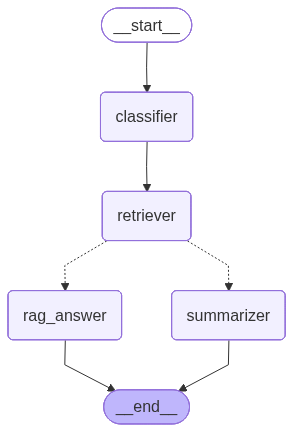

In [16]:
workflow = StateGraph(AgentState)

# Добавляем узлы в граф
workflow.add_node("classifier", classifier_node)
workflow.add_node("retriever", retriever_node)
workflow.add_node("summarizer", summarization_node)
workflow.add_node("rag_answer", rag_node)

# Строим связи
workflow.set_entry_point("classifier")
workflow.add_edge("classifier", "retriever")

# Условный переход: после ретривера идем либо в суммаризацию, либо в RAG
def decide_path(state: AgentState):
    if state["intent"] == "summarize":
        return "summarizer"
    return "rag_answer"

workflow.add_conditional_edges(
    "retriever",
    decide_path,
    {
        "summarizer": "summarizer",
        "rag_answer": "rag_answer"
    }
)

# Завершение
workflow.add_edge("summarizer", END)
workflow.add_edge("rag_answer", END)

# Компиляция
app = workflow.compile()
app

In [17]:
# Пример 1: Поисковый запрос
inputs = {"query": "Найди статьи про attention и сделай обзор"}
result = app.invoke(inputs)
print(result['final_answer'])

# Пример 2: Конкретный вопрос
inputs = {"query": "Что такое RAG?"}
result = app.invoke(inputs)
print(result['final_answer'])

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Суммаризация статьи: the effect of domain and diacritics in yorùbá-english neural machine translation


Adding requests:   0%|          | 0/29 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/29 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

 На основе предоставленного контекста невозможно определить, что такое RAG. Контекст не содержит информации о RAG. 

Объяснение: В предоставленном тексте не упоминается термин "RAG". Все сведения касаются математических доказательств, теории перестановок, свойств перестановок, а также логических и алгебраических конструкций, связанных с перестановками и их свойствами. Отсутствие упоминания термина "RAG" в тексте делает невозможным его определение на основе этого контекста. Следовательно, ответ — "На основе предоставленного контекста невозможно определить, что такое RAG". Это логичное и обоснованное заключение, поскольку контекст не содержит необходимой информации. 

Таким образом, правильный ответ: **На основе предоставленного контекста невозможно определить, что такое RAG.**. 

(Примечание: RAG — это, возможно, сокращение от "Retrieval-Augmented Generation", которое используется в области искусственного интеллекта и машинного обучения, но это не связано с содержанием предоставленного 